# 04b. Training Models — Sin preentrenamiento (scratch)

Mismo pipeline que `04_training_models.ipynb`, pero con `pretrained=False`: los 4 modelos arrancan con pesos **aleatorios**, no con los de ImageNet.

Objetivo: comparar cuánto ayuda el transfer learning en este dataset. Se espera que:
- Converja **más lento** y de forma **más ruidosa** que la versión preentrenada.
- Los CNN (ResNet-50, EfficientNet-B0) probablemente rindan mejor desde cero que los transformers (Swin, ViT), que suelen necesitar datasets grandes o preentrenamiento fuerte.

Por eso aquí `MAX_EPOCHS` y `PATIENCE` son más altos que en la versión preentrenada.

Checkpoints → `data/06_models/scratch/` (carpeta separada, no pisa los checkpoints preentrenados).

Resultados en texto/CSV → `data/08_reporting/*_scratch.*`

## 1. Configuración

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data.dataset import create_dataloaders
from src.models.train import train_model
from src.utils.helpers import get_device, set_seed

DATA_DIR = ROOT / "data"
MODELS_DIR = DATA_DIR / "06_models" / "scratch"
FIGURES_DIR = ROOT / "reports" / "figures"
REPORT_DIR = DATA_DIR / "08_reporting"

PRETRAINED = False

BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_EPOCHS = 60
PATIENCE = 10
LR = 1e-4
SEED = 42

MODELS = [
    {"name": "efficientnet_b0",              "label": "EfficientNet-B0 (scratch)"},
    {"name": "resnet50",                     "label": "ResNet-50 (scratch)"},
    {"name": "swin_tiny_patch4_window7_224", "label": "Swin Transformer (scratch)"},
    {"name": "vit_tiny_patch16_224",         "label": "ViT tiny (scratch)"},
]

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)
device = get_device()
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else str(device)

print(f"Device: {device}")
print(f"GPU: {gpu_name}")
print(f"PyTorch: {torch.__version__}")
print(f"Pretrained: {PRETRAINED}")
print(f"Batch={BATCH_SIZE} | Max epochs={MAX_EPOCHS} | Patience={PATIENCE} | LR={LR}")

c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 5060
PyTorch: 2.12.0.dev20260408+cu128
Pretrained: False
Batch=32 | Max epochs=60 | Patience=10 | LR=0.0001


## 2. DataLoaders

In [2]:
loaders = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

print(f"Train: {len(train_loader.dataset):,} chips | {len(train_loader):,} batches")
print(f"Val:   {len(val_loader.dataset):,} chips")
print(f"Test:  {len(test_loader.dataset):,} chips (notebook 05)")

Train: 81,938 chips | 2,561 batches
Val:   14,840 chips
Test:  14,806 chips (notebook 05)


## 3. Helpers — gráficos y exportación

In [3]:
def history_to_dataframe(summary: dict) -> pd.DataFrame:
    """Combina métricas train/val por epoch en un DataFrame."""
    train_df = pd.DataFrame(summary["history"]["train"]).add_prefix("train_")
    val_df = pd.DataFrame(summary["history"]["val"]).add_prefix("val_")
    if "train_epoch" in train_df.columns:
        train_df = train_df.rename(columns={"train_epoch": "epoch"})
    if "val_epoch" in val_df.columns:
        val_df = val_df.drop(columns=["val_epoch"])
    df = pd.concat([train_df, val_df], axis=1)
    df.insert(0, "model", summary.get("model_label", summary["model_name"]))
    df.insert(1, "timm_name", summary["model_name"])
    return df


def plot_training_curves(summary: dict, save_path: Path) -> None:
    history = summary["history"]
    label = summary.get("model_label", summary["model_name"])
    epochs = [r["epoch"] for r in history["train"]]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].plot(epochs, [r["loss"] for r in history["train"]], label="train")
    axes[0].plot(epochs, [r["loss"] for r in history["val"]], label="val")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("epoch")

    axes[1].plot(epochs, [r["accuracy"] for r in history["train"]], label="train")
    axes[1].plot(epochs, [r["accuracy"] for r in history["val"]], label="val")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("epoch")

    axes[2].plot(epochs, [r["macro_f1"] for r in history["val"]], label="val macro F1", color="tomato")
    axes[2].plot(epochs, [r["recall_com_garimpo"] for r in history["val"]], label="val recall com_garimpo")
    axes[2].set_title("Val F1 / Recall com_garimpo"); axes[2].legend(); axes[2].set_xlabel("epoch")

    plt.suptitle(f"{label} — curvas de entrenamiento", y=1.02)
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def format_epoch_line(epoch: int, max_ep: int, train_r: dict, val_r: dict, elapsed: float) -> str:
    return (
        f"Epoch {epoch:02d}/{max_ep} | "
        f"train loss {train_r['loss']:.4f} acc {train_r['accuracy']:.3f} | "
        f"val loss {val_r['loss']:.4f} acc {val_r['accuracy']:.3f} "
        f"F1 {val_r['macro_f1']:.3f} "
        f"(com recall {val_r['recall_com_garimpo']:.3f}) | "
        f"{elapsed:.0f}s"
    )

## 4. Entrenar los 4 modelos (sin preentrenamiento)


[1/4] Entrenando: EfficientNet-B0 (scratch) (efficientnet_b0)


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando efficientnet_b0 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/60 | train loss 0.7251 acc 0.614 | val loss 0.6925 acc 0.611 F1 0.596 (com recall 0.460) | 245s
  → Mejor modelo guardado (macro F1 = 0.5961)


Epoch 02/60 | train loss 0.6533 acc 0.645 | val loss 0.6402 acc 0.643 F1 0.620 (com recall 0.439) | 154s
  → Mejor modelo guardado (macro F1 = 0.6197)


...

Epoch 47/60 | train loss 0.4757 acc 0.762 | val loss 0.5610 acc 0.694 F1 0.690 (com recall 0.899) | 168s


Epoch 48/60 | train loss 0.4738 acc 0.765 | val loss 0.5203 acc 0.728 F1 0.728 (com recall 0.814) | 168s


Epoch 49/60 | train loss 0.4735 acc 0.764 | val loss 0.5586 acc 0.692 F1 0.690 (com recall 0.853) | 169s


Epoch 50/60 | train loss 0.4719 acc 0.764 | val loss 0.5553 acc 0.698 F1 0.696 (com recall 0.879) | 166s


Epoch 51/60 | train loss 0.4709 acc 0.767 | val loss 0.5628 acc 0.681 F1 0.676 (com recall 0.893) | 169s
Early stopping en epoch 51 (sin mejora en 10 epochs)

Listo. Mejor epoch: 41 | val macro F1: 0.7431
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\scratch\efficientnet_b0_best.pt


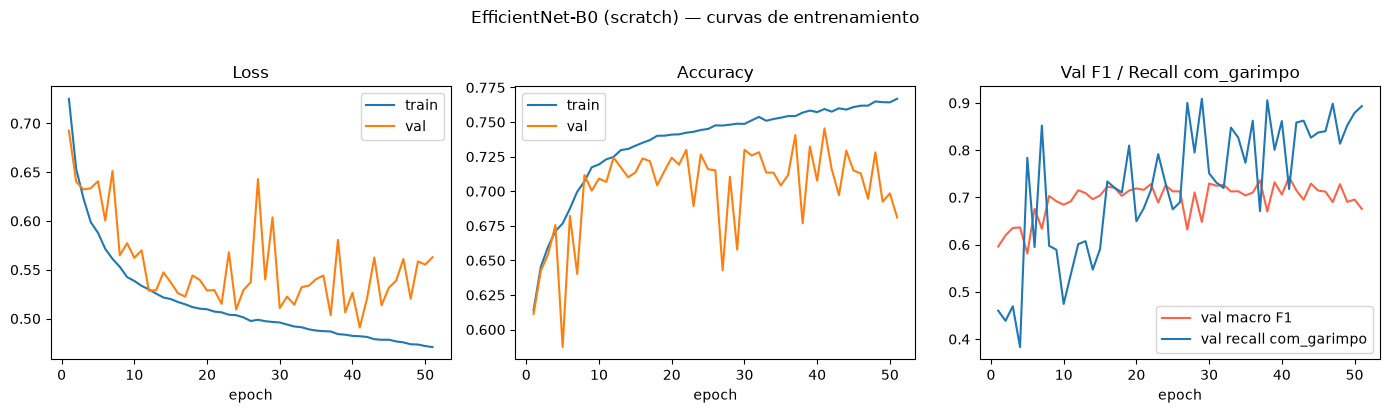


[2/4] Entrenando: ResNet-50 (scratch) (resnet50)


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando resnet50 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/60 | train loss 0.5782 acc 0.675 | val loss 0.8337 acc 0.635 F1 0.545 (com recall 0.210) | 162s
  → Mejor modelo guardado (macro F1 = 0.5454)


Epoch 02/60 | train loss 0.5465 acc 0.709 | val loss 0.5423 acc 0.724 F1 0.713 (com recall 0.580) | 127s
  → Mejor modelo guardado (macro F1 = 0.7128)


...

Epoch 24/60 | train loss 0.4747 acc 0.764 | val loss 0.5284 acc 0.707 F1 0.694 (com recall 0.546) | 137s


Epoch 25/60 | train loss 0.4721 acc 0.764 | val loss 2.2463 acc 0.596 F1 0.466 (com recall 0.113) | 126s


Epoch 26/60 | train loss 0.4710 acc 0.766 | val loss 0.7483 acc 0.666 F1 0.600 (com recall 0.286) | 133s


Epoch 27/60 | train loss 0.4693 acc 0.768 | val loss 0.9877 acc 0.614 F1 0.587 (com recall 0.961) | 129s


Epoch 28/60 | train loss 0.4678 acc 0.768 | val loss 0.8524 acc 0.693 F1 0.644 (com recall 0.356) | 128s
Early stopping en epoch 28 (sin mejora en 10 epochs)

Listo. Mejor epoch: 18 | val macro F1: 0.7462
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\scratch\resnet50_best.pt


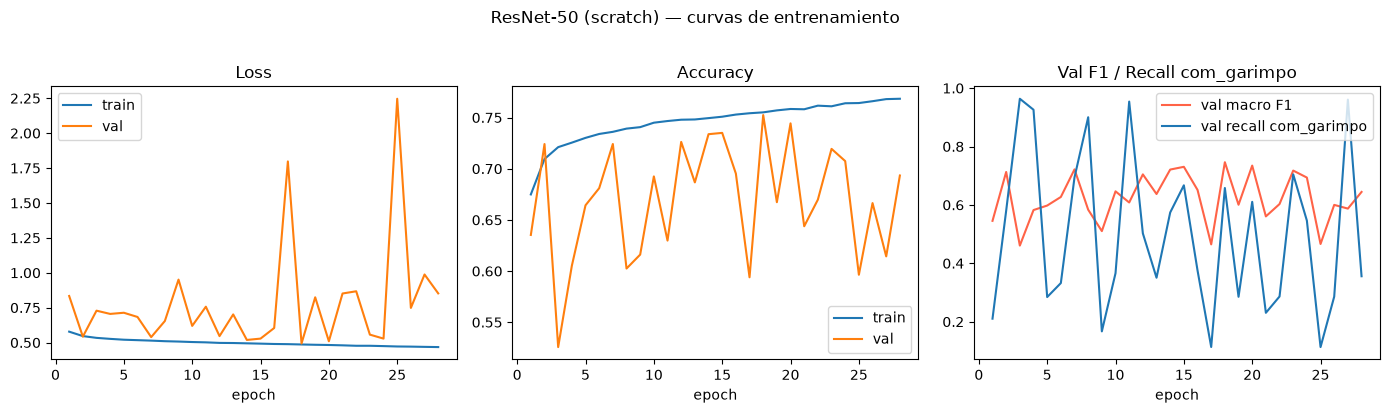


[3/4] Entrenando: Swin Transformer (scratch) (swin_tiny_patch4_window7_224)


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando swin_tiny_patch4_window7_224 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/60 | train loss 0.6934 acc 0.546 | val loss 0.7403 acc 0.453 F1 0.312 (com recall 1.000) | 199s
  → Mejor modelo guardado (macro F1 = 0.3118)


Epoch 02/60 | train loss 0.6883 acc 0.555 | val loss 0.7035 acc 0.453 F1 0.312 (com recall 1.000) | 193s


...

Epoch 07/60 | train loss 0.6861 acc 0.561 | val loss 0.7076 acc 0.453 F1 0.312 (com recall 1.000) | 192s


Epoch 08/60 | train loss 0.6861 acc 0.560 | val loss 0.7094 acc 0.453 F1 0.312 (com recall 1.000) | 192s


Epoch 09/60 | train loss 0.6860 acc 0.561 | val loss 0.7130 acc 0.453 F1 0.312 (com recall 1.000) | 191s


Epoch 10/60 | train loss 0.6860 acc 0.561 | val loss 0.6974 acc 0.453 F1 0.312 (com recall 1.000) | 191s


Epoch 11/60 | train loss 0.6861 acc 0.561 | val loss 0.7195 acc 0.453 F1 0.312 (com recall 1.000) | 194s
Early stopping en epoch 11 (sin mejora en 10 epochs)

Listo. Mejor epoch: 1 | val macro F1: 0.3118
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\scratch\swin_tiny_patch4_window7_224_best.pt


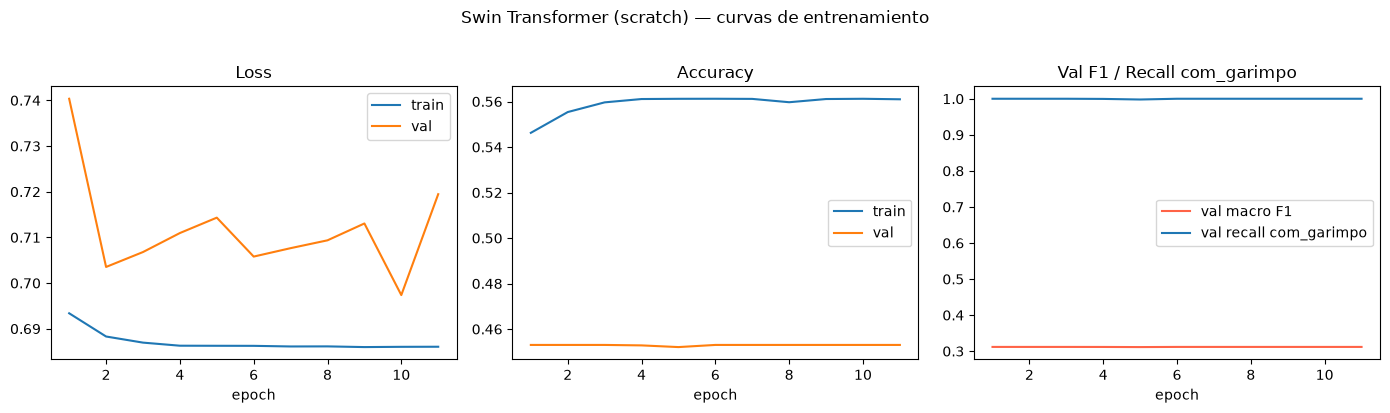

C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None



[4/4] Entrenando: ViT tiny (scratch) (vit_tiny_patch16_224)
Entrenando vit_tiny_patch16_224 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/60 | train loss 0.6258 acc 0.601 | val loss 0.5956 acc 0.706 F1 0.680 (com recall 0.469) | 122s
  → Mejor modelo guardado (macro F1 = 0.6805)


Epoch 02/60 | train loss 0.6043 acc 0.636 | val loss 0.6373 acc 0.619 F1 0.609 (com recall 0.862) | 116s


Epoch 03/60 | train loss 0.5941 acc 0.648 | val loss 0.6115 acc 0.636 F1 0.625 (com recall 0.890) | 115s


...

Epoch 14/60 | train loss 0.5480 acc 0.698 | val loss 0.6136 acc 0.623 F1 0.611 (com recall 0.878) | 121s


Epoch 15/60 | train loss 0.5445 acc 0.701 | val loss 0.6265 acc 0.615 F1 0.609 (com recall 0.817) | 120s


Epoch 16/60 | train loss 0.5423 acc 0.704 | val loss 0.5745 acc 0.682 F1 0.680 (com recall 0.666) | 124s


Epoch 17/60 | train loss 0.5392 acc 0.708 | val loss 0.5629 acc 0.691 F1 0.689 (com recall 0.681) | 112s


Epoch 18/60 | train loss 0.5385 acc 0.709 | val loss 0.5515 acc 0.708 F1 0.684 (com recall 0.472) | 118s
Early stopping en epoch 18 (sin mejora en 10 epochs)

Listo. Mejor epoch: 8 | val macro F1: 0.7163
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\scratch\vit_tiny_patch16_224_best.pt


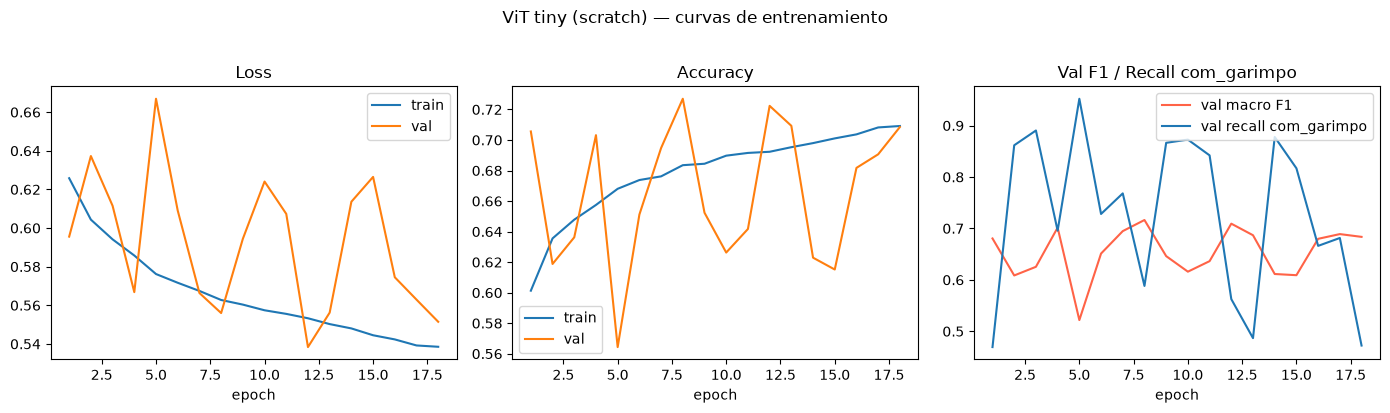


Entrenamiento (scratch) completado.


In [4]:
results = []
all_epochs_dfs = []
log_lines = [
    "TRAINING MODELS (SCRATCH, SIN PREENTRENAMIENTO) — RESULTADOS",
    f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
    f"Device: {device} | GPU: {gpu_name}",
    f"PyTorch: {torch.__version__}",
    f"Pretrained: {PRETRAINED}",
    f"Batch={BATCH_SIZE} | Max epochs={MAX_EPOCHS} | Patience={PATIENCE} | LR={LR}",
    f"Train chips: {len(train_loader.dataset):,} | Val: {len(val_loader.dataset):,}",
    "",
]

for i, model_cfg in enumerate(MODELS, start=1):
    name = model_cfg["name"]
    label = model_cfg["label"]

    print("\n" + "=" * 60)
    print(f"[{i}/{len(MODELS)}] Entrenando: {label} ({name})")
    print("=" * 60)

    log_lines += ["=" * 60, f"MODELO: {label} ({name})", "=" * 60, ""]

    summary = train_model(
        model_name=name,
        train_loader=train_loader,
        val_loader=val_loader,
        save_dir=MODELS_DIR,
        device=device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        lr=LR,
        pretrained=PRETRAINED,
    )
    summary["model_label"] = label

    # CSV por epoch de este modelo
    epoch_df = history_to_dataframe(summary)
    epoch_csv = REPORT_DIR / f"epochs_{name}_scratch.csv"
    epoch_df.to_csv(epoch_csv, index=False)
    all_epochs_dfs.append(epoch_df)

    # Líneas de texto por epoch
    for tr, va in zip(summary["history"]["train"], summary["history"]["val"]):
        log_lines.append(format_epoch_line(
            tr["epoch"], MAX_EPOCHS, tr, va, tr.get("time_s", 0)
        ))

    val_history = summary["history"]["val"]
    best_val = next(r for r in val_history if r["epoch"] == summary["best_epoch"])

    log_lines += [
        "",
        f"→ Mejor epoch: {summary['best_epoch']} | val macro F1: {summary['best_val_macro_f1']:.4f}",
        f"→ val accuracy: {best_val['accuracy']:.4f} | val recall com_garimpo: {best_val['recall_com_garimpo']:.4f}",
        f"→ Checkpoint: {summary['checkpoint']}",
        f"→ CSV epochs: {epoch_csv}",
        "",
    ]

    plot_training_curves(summary, FIGURES_DIR / f"{name}_scratch_training_curves.png")

    results.append({
        "model": label,
        "timm_name": name,
        "pretrained": PRETRAINED,
        "best_epoch": summary["best_epoch"],
        "epochs_run": len(summary["history"]["train"]),
        "val_macro_f1": round(summary["best_val_macro_f1"], 4),
        "val_accuracy": round(best_val["accuracy"], 4),
        "val_recall_com_garimpo": round(best_val["recall_com_garimpo"], 4),
        "val_f1_com_garimpo": round(best_val["f1_com_garimpo"], 4),
        "val_f1_sem_garimpo": round(best_val["f1_sem_garimpo"], 4),
        "checkpoint": summary["checkpoint"],
    })

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nEntrenamiento (scratch) completado.")

## 5. Guardar resumen (CSV + TXT)

In [5]:
results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
display(results_df)

# CSV resumen comparativo
summary_csv = REPORT_DIR / "training_results_summary_scratch.csv"
results_df.to_csv(summary_csv, index=False)

# CSV todas las epochs de los 4 modelos
all_epochs_csv = REPORT_DIR / "training_epochs_all_models_scratch.csv"
pd.concat(all_epochs_dfs, ignore_index=True).to_csv(all_epochs_csv, index=False)

# TXT legible
best = results_df.iloc[0]
log_lines += [
    "=" * 60,
    "RESUMEN COMPARATIVO (validation, scratch)",
    "=" * 60,
    "",
    results_df.to_string(index=False),
    "",
    f"MEJOR MODELO (SCRATCH): {best['model']} | val macro F1 = {best['val_macro_f1']}",
    f"Checkpoint: {best['checkpoint']}",
]

summary_txt = REPORT_DIR / "training_results_scratch.txt"
summary_txt.write_text("\n".join(log_lines), encoding="utf-8")

print(f"\nArchivos guardados:")
print(f"  {summary_csv}")
print(f"  {all_epochs_csv}")
print(f"  {summary_txt}")
print(f"\nMejor modelo (scratch): {best['model']} (val F1={best['val_macro_f1']})")

,model,timm_name,pretrained,best_epoch,epochs_run,val_macro_f1,val_accuracy,val_recall_com_garimpo,val_f1_com_garimpo,val_f1_sem_garimpo,checkpoint
1,ResNet-50 (scratch),resnet50,False,18,28,0.7462,0.7524,0.6579,0.7065,0.7859,C:\Users\luisg\OneDrive\Documentos\Universidad...
0,EfficientNet-B0 (scratch),efficientnet_b0,False,41,51,0.7431,0.7454,0.7178,0.7187,0.7675,C:\Users\luisg\OneDrive\Documentos\Universidad...
3,ViT tiny (scratch),vit_tiny_patch16_224,False,8,18,0.7163,0.7270,0.5881,0.6613,0.7714,C:\Users\luisg\OneDrive\Documentos\Universidad...
2,Swin Transformer (scratch),swin_tiny_patch4_window7_224,False,1,11,0.3118,0.4530,1.0000,0.6236,0.0000,C:\Users\luisg\OneDrive\Documentos\Universidad...



Archivos guardados:
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\training_results_summary_scratch.csv
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\training_epochs_all_models_scratch.csv
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\training_results_scratch.txt

Mejor modelo (scratch): ResNet-50 (scratch) (val F1=0.7462)


## 6. Comparación rápida: preentrenado vs. scratch

In [6]:
pretrained_csv = REPORT_DIR / "training_results_summary.csv"

if pretrained_csv.exists():
    pre_df = pd.read_csv(pretrained_csv)[["timm_name", "val_macro_f1", "val_accuracy"]]
    pre_df = pre_df.rename(columns={"val_macro_f1": "val_macro_f1_pretrained",
                                     "val_accuracy": "val_accuracy_pretrained"})

    scratch_df = results_df[["timm_name", "val_macro_f1", "val_accuracy"]].rename(
        columns={"val_macro_f1": "val_macro_f1_scratch", "val_accuracy": "val_accuracy_scratch"}
    )

    compare = pre_df.merge(scratch_df, on="timm_name", how="outer")
    compare["f1_gap_pretrained_minus_scratch"] = (
        compare["val_macro_f1_pretrained"] - compare["val_macro_f1_scratch"]
    ).round(4)
    display(compare.sort_values("f1_gap_pretrained_minus_scratch", ascending=False))

    compare_csv = REPORT_DIR / "pretrained_vs_scratch_comparison.csv"
    compare.to_csv(compare_csv, index=False)
    print(f"\nGuardado: {compare_csv}")
else:
    print("No se encontró training_results_summary.csv (corrida con pretrained=True).")

,timm_name,val_macro_f1_pretrained,val_accuracy_pretrained,val_macro_f1_scratch,val_accuracy_scratch,f1_gap_pretrained_minus_scratch
2,swin_tiny_patch4_window7_224,0.7456,0.7456,0.3118,0.4530,0.4338
1,resnet50,0.7619,0.7627,0.7462,0.7524,0.0157
3,vit_tiny_patch16_224,0.7231,0.7280,0.7163,0.7270,0.0068
0,efficientnet_b0,0.7489,0.7491,0.7431,0.7454,0.0058



Guardado: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\pretrained_vs_scratch_comparison.csv


## 7. Próximo paso

Evaluar estos checkpoints (`data/06_models/scratch/`) en **test** — se puede reusar `05_evaluation.ipynb` apuntando `MODELS_DIR` a esta carpeta, o correrlo dos veces (una por cada carpeta de checkpoints).